In [2]:
import mne

raw = mne.io.read_raw_edf(
    "SC4001E0-PSG.edf",
    preload=True
)

print(raw.info)

Extracting EDF parameters from SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...


/tmp/ipykernel_5277/429854263.py:3: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_5277/429854263.py:3: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/tmp/ipykernel_5277/429854263.py:3: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(


Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: 1989-04-24 16:13:00 UTC
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: <subject_info | his_id: X, sex: 2, first_name: Female, last_name: 33yr>
>


In [3]:
print(raw.ch_names)

['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']


In [4]:
raw.pick(["EEG Fpz-Cz"])

<RawEDF | SC4001E0-PSG.edf, 1 x 7950000 (79500.0 s), ~60.7 MiB, data loaded>

Using matplotlib as 2D backend.


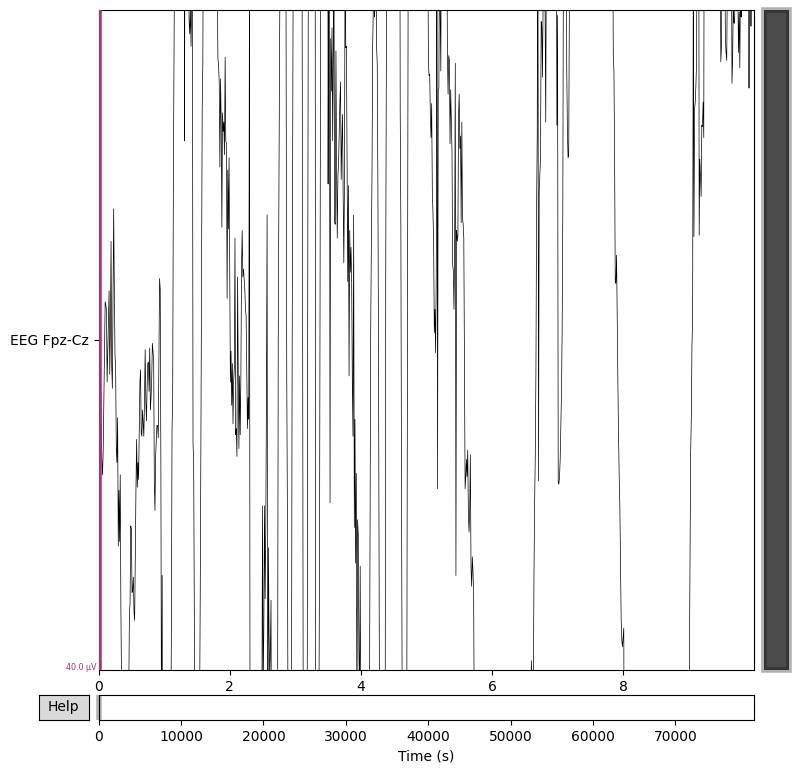

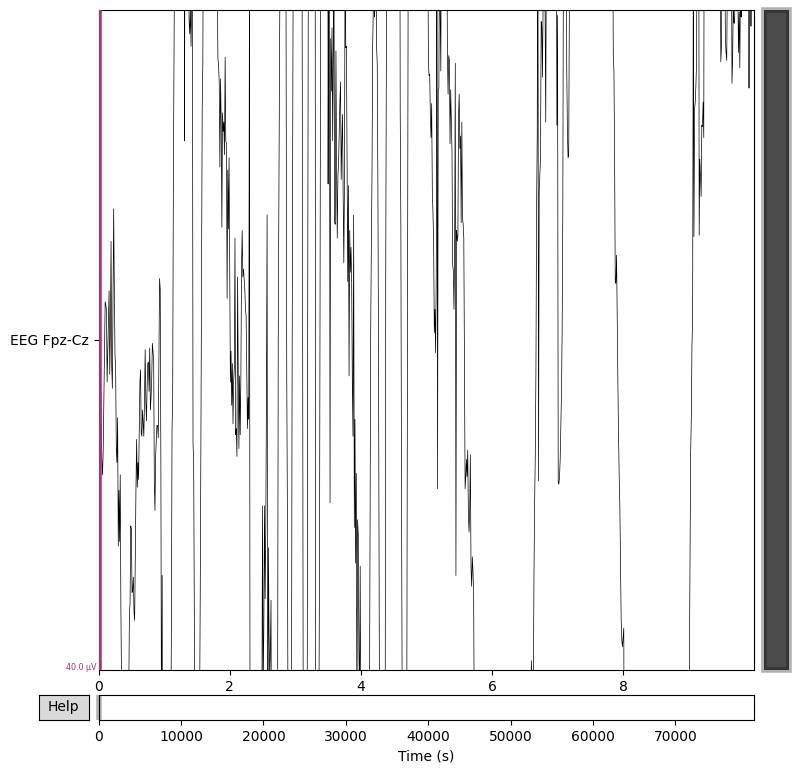

In [5]:
raw.plot(duration=10)

In [6]:
raw.filter(0.5, 30)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 661 samples (6.610 s)



<RawEDF | SC4001E0-PSG.edf, 1 x 7950000 (79500.0 s), ~60.7 MiB, data loaded>

Effective window size : 20.480 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/tmp/ipykernel_5277/4108630121.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd().plot()


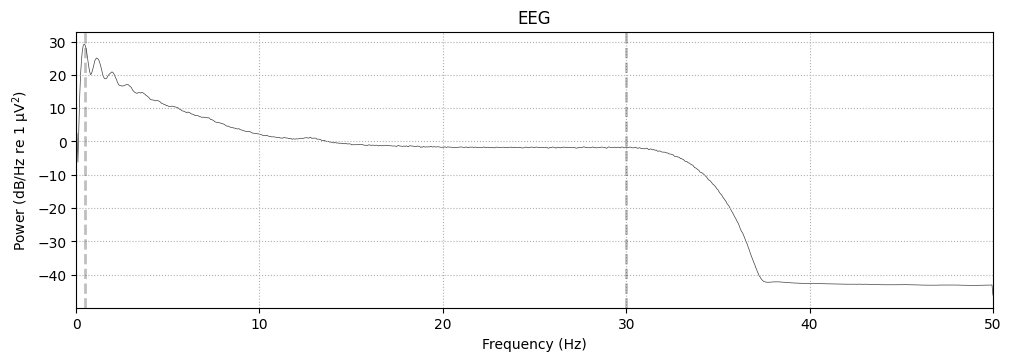

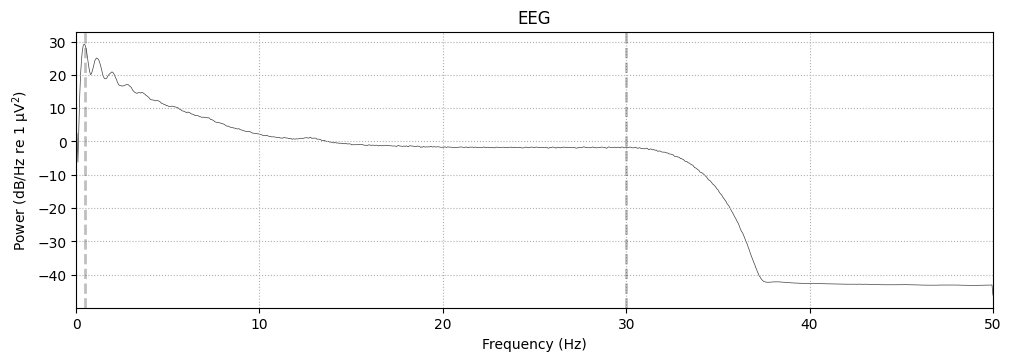

In [7]:
raw.compute_psd().plot()

In [8]:
annot = mne.read_annotations(
    "SC4001EC-Hypnogram.edf"
)

raw.set_annotations(annot)

/tmp/ipykernel_5277/1361154162.py:5: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annot)


<RawEDF | SC4001E0-PSG.edf, 1 x 7950000 (79500.0 s), ~60.7 MiB, data loaded>

In [9]:
epochs = mne.make_fixed_length_epochs(
    raw,
    duration=30,
    preload=True
)

print(epochs)

Not setting metadata
2650 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2650 events and 3000 original time points ...
0 bad epochs dropped
<Epochs | 2650 events (all good), 0 – 29.99 s (baseline off), ~60.7 MiB, data loaded,
 '1': 2650>


In [10]:
import numpy as np

data = epochs.get_data()

features = np.mean(data, axis=2)

print(features.shape)

(2650, 1)


In [12]:
labels = np.random.randint(0, 2, len(features))

In [13]:
<Epochs | 2650 events (all good)>

SyntaxError: invalid syntax (3077962795.py, line 1)

In [14]:
import numpy as np

data = epochs.get_data()

print(data.shape)

(2650, 1, 3000)


In [15]:
features = np.mean(data, axis=2)

print(features.shape)

(2650, 1)


In [16]:
variance = np.var(data, axis=2)
maximum = np.max(data, axis=2)

X = np.concatenate(
    [features, variance, maximum],
    axis=1
)

print(X.shape)

(2650, 3)


In [17]:
labels = np.random.randint(0, 2, len(X))

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X,
    labels,
    test_size=0.2,
    random_state=42
)

clf = RandomForestClassifier()

clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.45      0.54      0.49       237
           1       0.55      0.47      0.51       293

    accuracy                           0.50       530
   macro avg       0.50      0.50      0.50       530
weighted avg       0.51      0.50      0.50       530



In [19]:
print(raw.annotations.description[:20])

['Sleep stage W' 'Sleep stage 1' 'Sleep stage 2' 'Sleep stage 3'
 'Sleep stage 2' 'Sleep stage 3' 'Sleep stage 4' 'Sleep stage 3'
 'Sleep stage 4' 'Sleep stage 3' 'Sleep stage 4' 'Sleep stage 3'
 'Sleep stage 4' 'Sleep stage W' 'Sleep stage 3' 'Sleep stage 2'
 'Sleep stage 3' 'Sleep stage 4' 'Sleep stage 3' 'Sleep stage 4']


In [20]:
events, event_id = mne.events_from_annotations(raw)

print(event_id)

Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage ?'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
{np.str_('Sleep stage 1'): 1, np.str_('Sleep stage 2'): 2, np.str_('Sleep stage 3'): 3, np.str_('Sleep stage 4'): 4, np.str_('Sleep stage ?'): 5, np.str_('Sleep stage R'): 6, np.str_('Sleep stage W'): 7}


In [21]:
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=0,
    tmax=30,
    baseline=None,
    preload=True
)

Not setting metadata
154 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 154 events and 3001 original time points ...
1 bad epochs dropped
